In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [109]:
syns = pd.read_csv("synapses.csv")
syns['spike_train']

0        [54 204 570 609 1023 1313 1674 1989 2213 2252 ...
1        [201 399 427 646 692 836 1213 1460 1656 2120 2...
2        [528 538 546 696 1002 1113 1898 1905 2540 2825...
3        [156 544 662 830 914 1128 1310 2186 2931 3694 ...
4        [113 431 679 1103 1190 1268 1380 1728 1777 188...
                               ...                        
21195    [10 71 214 275 346 352 376 406 744 827 949 969...
21196    [54 101 269 297 329 394 450 464 536 619 637 67...
21197    [15 22 33 77 128 180 196 266 449 455 488 525 6...
21198    [6 37 138 160 174 230 278 302 343 349 367 398 ...
21199    [338 400 410 435 461 564 602 728 776 780 837 8...
Name: spike_train, Length: 21200, dtype: object

In [110]:
syns.columns

Index(['name', 'modfile', 'P_0', 'initW', 'cell2cell_type', 'seg_id',
       'gbar_ampa', 'gbar_nmda', 'gbar_gaba', 'functional_group',
       'presynaptic_cell', 'spike_train', 'pc_mean_firing_rate'],
      dtype='object')

In [111]:
syns['name'].value_counts()

name
exc_tuft_0               1
exc_distal_basal_6035    1
exc_distal_basal_6033    1
exc_distal_basal_6032    1
exc_distal_basal_6031    1
                        ..
exc_oblique_1060         1
exc_oblique_1059         1
exc_oblique_1058         1
exc_oblique_1057         1
inh_perisomatic_201      1
Name: count, Length: 21200, dtype: int64

In [112]:
def parse_spike_train(st):
    out = np.zeros(10000)
    for spk_time in st[1:-1].split(" "):
        try:
            out[int(spk_time)] = 1
        except:
            continue  
    return out

exc_tuft = syns[syns['name'].str.contains("inh_distal_basal")]['spike_train']

spike_trains = []
for row_idx in range(len(exc_tuft)):
    spike_trains.append(parse_spike_train(exc_tuft.iloc[row_idx]))

spike_trains = np.array(spike_trains).astype(int)

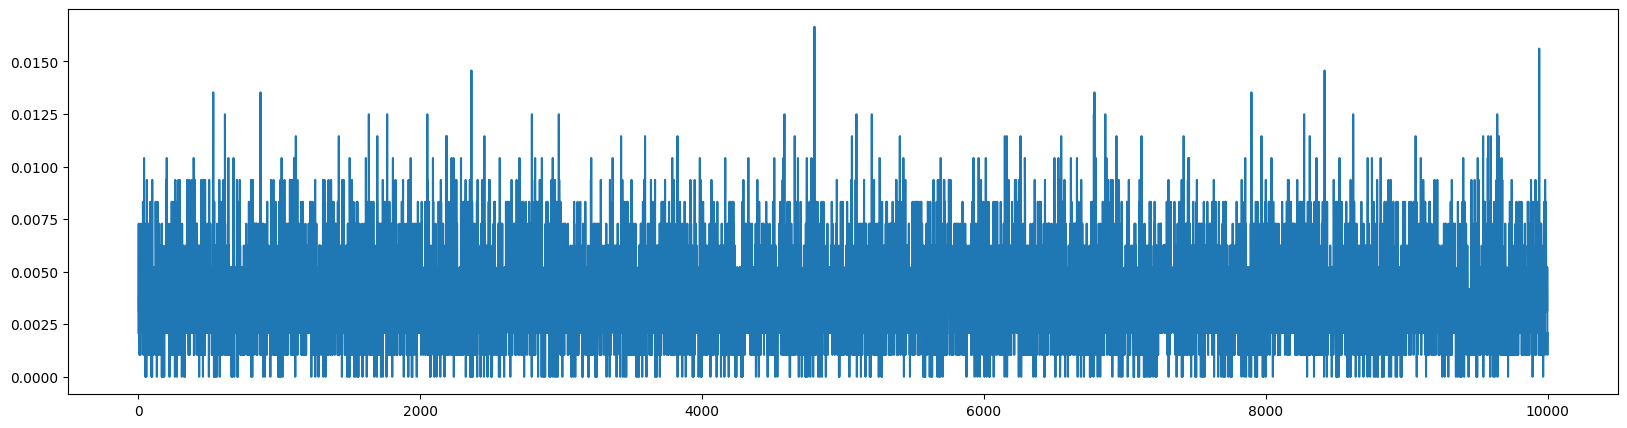

In [113]:
fig, ax = plt.subplots(1, 1, figsize = (20, 5))
plt.plot(spike_trains.mean(axis = 0))


FOOOF WARNING: Skipping frequency == 0, as this causes a problem with fitting.

FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 3.91
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                   FOOOF - POWER SPECTRUM MODEL                                   
                                                                                                  
                       The model was run on the frequency range 3 - 200 Hz                        
                                 Frequency Resolution is 3.91 Hz                                  
                                                                         

Text(0.5, 1.0, 'inh_distal_basal')

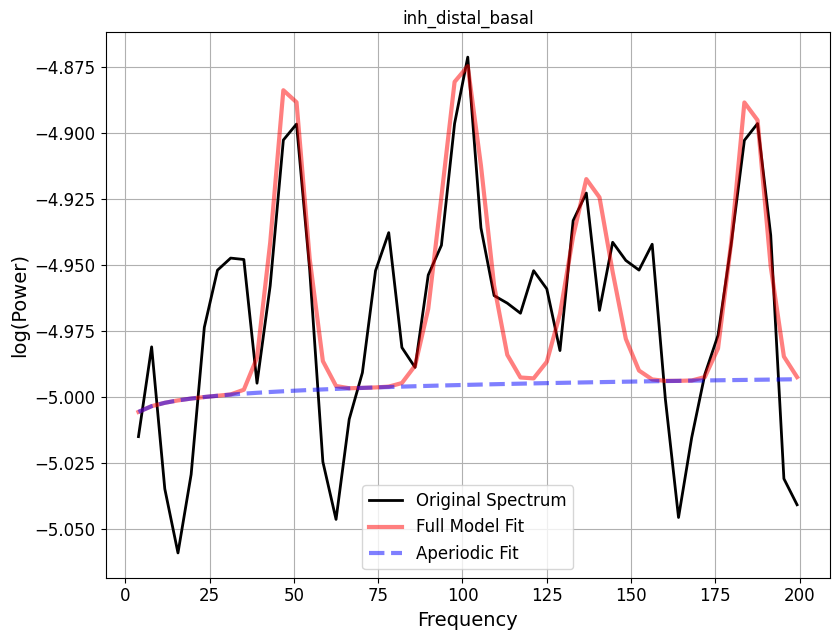

In [114]:
from scipy.signal import welch
from fooof import FOOOF

f, Pxx = welch(spike_trains[0], fs = 1000)
fm = FOOOF()
fm.report(f, Pxx, [0, 200])
plt.title("inh_distal_basal")